# Day 23 - Customer Order Correlation Analysis

## 분석 목적

고객 주문 데이터의 주요 수치형 변수 간 관계를
공분산과 Pearson 상관계수를 이용해 분석한다.

단순히 높은 상관계수를 찾는 데서 끝나지 않고,
실제 고객 행동 관계와 계산 구조에서 발생한 관계를 구분한다.

또한 관찰된 상관관계를 인과관계로 해석할 수 있는지 검토한다.

## 분석 질문

1. 고객의 총 주문 수와 함께 움직이는 변수는 무엇인가?
2. 총 주문 수와 최근 주문 경과일은 어떤 관계가 있는가?
3. 총 주문 수와 고객 활동 기간은 어떤 관계가 있는가?
4. 계산 구조로 인해 높게 나타나는 상관관계가 존재하는가?
5. 관찰된 상관관계를 인과관계로 해석할 수 있는가?

## 주요 개념

### 공분산

두 변수가 평균을 기준으로 함께 움직이는 방향을 나타낸다.

- 양수: 같은 방향으로 움직이는 경향
- 음수: 반대 방향으로 움직이는 경향
- 0 근처: 선형적인 공동 움직임이 약함

### Pearson 상관계수

공분산을 두 변수의 표준편차로 나누어 표준화한 값이다.

범위:

-1 <= r <= 1

- r > 0: 양의 선형 관계
- r < 0: 음의 선형 관계
- r ≈ 0: 선형 관계가 약함

상관관계는 인과관계를 의미하지 않는다.

In [1]:
# 라이브러리 불러오기
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 경로 설정
project_root = Path.cwd().parent

input_path = (
    project_root
    / "outputs"
    / "customer_order_mini_project.csv"
)

output_dir = project_root / "outputs"

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(input_path)
print(input_path.exists())

d:\Study\Projects\00_foundation_review\outputs\customer_order_mini_project.csv
True


In [4]:
# 데이터 불러오기
df = pd.read_csv(
    input_path
)

print(
    df.shape
)

df.head()


(30, 18)


,customer_id,customer_name,region,grade,total_order_count,paid_order_count,cancelled_order_count,paid_rate,first_order_date,last_order_date,data_reference_date,active_period_days,avg_days_between_orders,recency_days,avg_customer_order_count,order_count_rank,activity_status,management_action
0,1,Kim,Seoul,VIP,9,9,0,100.0,2026-01-15,2026-07-30,2026-07-31,196.0,24.5,1.0,3.47,1,recent,retention_priority
1,5,Han,Seoul,VIP,8,8,0,100.0,2025-12-20,2026-07-31,2026-07-31,223.0,31.9,0.0,3.47,2,recent,retention_priority
2,6,Jung,Busan,GOLD,7,6,1,85.7,2026-01-05,2026-07-24,2026-07-31,200.0,33.3,7.0,3.47,3,recent,retention_priority
3,9,Yoon,Daejeon,VIP,6,6,0,100.0,2026-01-07,2026-07-29,2026-07-31,203.0,40.6,2.0,3.47,4,recent,retention_priority
4,25,Bae,Incheon,VIP,6,6,0,100.0,2026-01-12,2026-07-31,2026-07-31,200.0,40.0,0.0,3.47,4,recent,retention_priority


In [5]:
# 데이터 구조확인
print(
    df.dtypes
)

print(
    df.isna().sum()
)

customer_id                   int64
customer_name                   str
region                          str
grade                           str
total_order_count             int64
paid_order_count              int64
cancelled_order_count         int64
paid_rate                   float64
first_order_date                str
last_order_date                 str
data_reference_date             str
active_period_days          float64
avg_days_between_orders     float64
recency_days                float64
avg_customer_order_count    float64
order_count_rank              int64
activity_status                 str
management_action               str
dtype: object
customer_id                 0
customer_name               0
region                      0
grade                       0
total_order_count           0
paid_order_count            0
cancelled_order_count       0
paid_rate                   0
first_order_date            5
last_order_date             5
data_reference_date         0
active_p

## 분석 변수 선택

숫자형 열이라고 해서 모두 상관분석 대상이 되는 것은 아니다.

예를 들어 customer_id는 숫자로 저장되어 있지만
숫자의 크기가 고객 특성의 크기를 의미하지 않으므로 제외한다.

이번 분석에서는 고객 주문 활동과 의미 있는
수치형 변수만 선택한다.

In [8]:
# 수치 변수 선택
numeric_columns = [
    "total_order_count",
    "paid_order_count",
    "cancelled_order_count",
    "paid_rate",
    "active_period_days",
    "avg_days_between_orders",
    "recency_days",
]

numeric_df = df[
    numeric_columns
]

numeric_df.head()

,total_order_count,paid_order_count,cancelled_order_count,paid_rate,active_period_days,avg_days_between_orders,recency_days
0,9,9,0,100.0,196.0,24.5,1.0
1,8,8,0,100.0,223.0,31.9,0.0
2,7,6,1,85.7,200.0,33.3,7.0
3,6,6,0,100.0,203.0,40.6,2.0
4,6,6,0,100.0,200.0,40.0,0.0


In [9]:
# 결측치 확인
missing_summary = (
    numeric_df
    .isna()
    .sum()
)

missing_summary

total_order_count          0
paid_order_count           0
cancelled_order_count      0
paid_rate                  0
active_period_days         6
avg_days_between_orders    6
recency_days               5
dtype: int64

중요한 점

상관분석을 위해:
fillna(0)
를 무조건 하지 않는다.

예를 들어 recency_days = 0은
최근 주문이 오늘 있었다.
라는 실제 의미이기 때문이다.

In [10]:
# 공분산 행렬
covariance_matrix = (
    numeric_df
    .cov()
)

covariance_matrix

,total_order_count,paid_order_count,cancelled_order_count,paid_rate,active_period_days,avg_days_between_orders,recency_days
total_order_count,5.636782,5.167816,0.468966,52.602529,85.934783,-15.492391,-30.813333
paid_order_count,5.167816,5.843678,-0.675862,69.513563,86.717391,-13.855435,-16.070000
cancelled_order_count,0.468966,-0.675862,1.144828,-16.911034,-0.782609,-1.636957,-14.743333
paid_rate,52.602529,69.513563,-16.911034,1609.036333,203.684783,0.891196,295.511833
active_period_days,85.934783,86.717391,-0.782609,203.684783,2984.000000,-147.939130,-1110.000000
avg_days_between_orders,-15.492391,-13.855435,-1.636957,0.891196,-147.939130,174.301087,133.145652
recency_days,-30.813333,-16.070000,-14.743333,295.511833,-1110.000000,133.145652,2061.860000


In [11]:
# 공분산 저장
covariance_output_path = (
    output_dir
    / "customer_order_covariance_matrix.csv"
)

covariance_matrix.to_csv(
    covariance_output_path
)

print(
    covariance_output_path.exists()
)

True


In [12]:
# 상관계수 행렬
correlation_matrix = (
    numeric_df
    .corr()
)

correlation_matrix

,total_order_count,paid_order_count,cancelled_order_count,paid_rate,active_period_days,avg_days_between_orders,recency_days
total_order_count,1.000000,0.900427,0.184610,0.552342,0.838499,-0.625463,-0.347806
paid_order_count,0.900427,1.000000,-0.261303,0.716875,0.713178,-0.471478,-0.158166
cancelled_order_count,0.184610,-0.261303,1.000000,-0.394019,-0.012441,-0.107672,-0.285503
paid_rate,0.552342,0.716875,-0.394019,1.000000,0.131305,0.002377,0.231916
active_period_days,0.838499,0.713178,-0.012441,0.131305,1.000000,-0.205132,-0.438189
avg_days_between_orders,-0.625463,-0.471478,-0.107672,0.002377,-0.205132,1.000000,0.217478
recency_days,-0.347806,-0.158166,-0.285503,0.231916,-0.438189,0.217478,1.000000


In [13]:
# 상관계수 행렬 저장
correlation_output_path = (
    output_dir
    / "customer_order_correlation_matrix.csv"
)

correlation_matrix.to_csv(
    correlation_output_path
)

print(
    correlation_output_path.exists()
)

True


In [15]:
# 총 주문 수 기준 상관관계 정리
order_correlation = (
    correlation_matrix[
        "total_order_count"
    ]
    .drop(
        "total_order_count"
    )
)

order_correlation_df = (
    order_correlation
    .rename_axis(
        "variable"
    )
    .reset_index(
        name="correlation"
    )
)

order_correlation_df[
    "abs_correlation"
] = (
    order_correlation_df[
        "correlation"
    ]
    .abs()
)

order_correlation_df = (
    order_correlation_df
    .sort_values(
        "abs_correlation",
        ascending=False
    )
)

order_correlation_df

,variable,correlation,abs_correlation
0,paid_order_count,0.900427,0.900427
3,active_period_days,0.838499,0.838499
4,avg_days_between_orders,-0.625463,0.625463
2,paid_rate,0.552342,0.552342
5,recency_days,-0.347806,0.347806
1,cancelled_order_count,0.184610,0.184610


In [16]:
# 요약표 저장
pair_output_path = (
    output_dir
    / "customer_order_pair_correlation_summary.csv"
)

order_correlation_df.to_csv(
    pair_output_path,
    index=False
)

print(
    pair_output_path.exists()
)

True


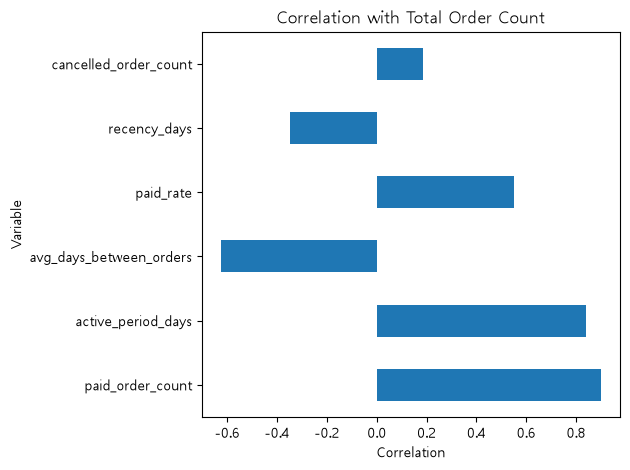

In [17]:
# 총 주문 수 상관계수 그래프
figure_path = (
    output_dir
    / "customer_order_count_correlation_bar.png"
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

order_correlation_df.plot.barh(
    x="variable",
    y="correlation",
    legend=False,
)

plt.title(
    "Correlation with Total Order Count"
)

plt.xlabel(
    "Correlation"
)

plt.ylabel(
    "Variable"
)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 총 주문 수와 최근 주문 경과일

상관계수만으로 관계를 판단하지 않고
산점도를 함께 확인한다.

특히 특정 고객 몇 명이 전체 상관계수를 크게 움직이고 있는지,
점들이 직선 형태를 보이는지 확인한다.

In [18]:
# 주문 수와 recency
order_recency_df = (
    df[
        [
            "total_order_count",
            "recency_days",
        ]
    ]
    .dropna()
)

order_recency_correlation = (
    order_recency_df[
        "total_order_count"
    ]
    .corr(
        order_recency_df[
            "recency_days"
        ]
    )
)

print(
    "분석 고객 수:",
    len(order_recency_df)
)

print(
    "상관계수:",
    order_recency_correlation
)

분석 고객 수: 25
상관계수: -0.3478056804926201


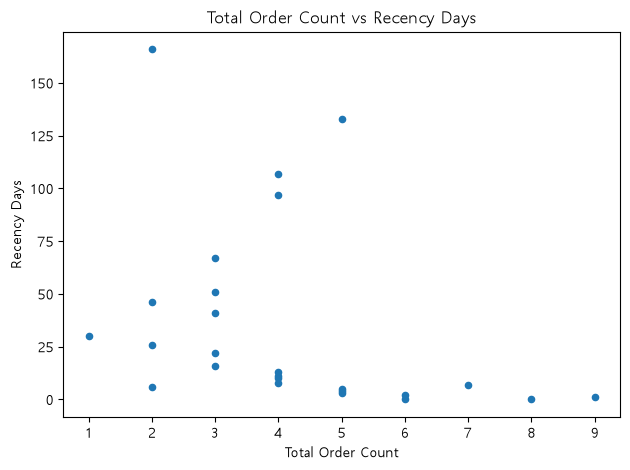

In [19]:
# 주문 수 vs recency 산점도
figure_path = (
    output_dir
    / "customer_order_count_vs_recency.png"
)

order_recency_df.plot.scatter(
    x="total_order_count",
    y="recency_days",
)

plt.title(
    "Total Order Count vs Recency Days"
)

plt.xlabel(
    "Total Order Count"
)

plt.ylabel(
    "Recency Days"
)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# 주문 수와 활동 기간
order_active_df = (
    df[
        [
            "total_order_count",
            "active_period_days",
        ]
    ]
    .dropna()
)

order_active_correlation = (
    order_active_df[
        "total_order_count"
    ]
    .corr(
        order_active_df[
            "active_period_days"
        ]
    )
)

print(
    "분석 고객 수:",
    len(order_active_df)
)

print(
    "상관계수:",
    order_active_correlation
)

분석 고객 수: 24
상관계수: 0.8384993143709598


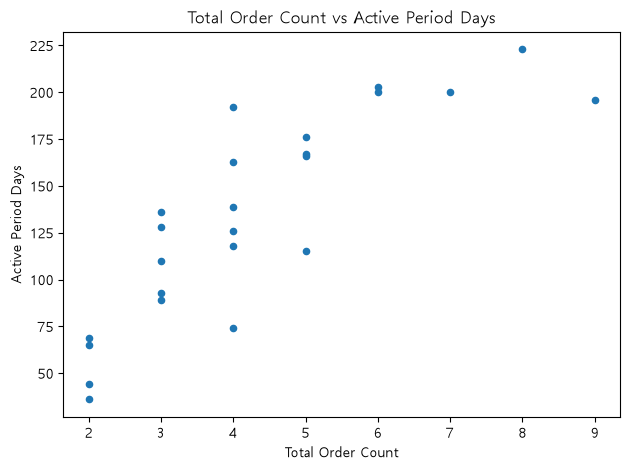

In [21]:
# 활동 기간 산점도
figure_path = (
    output_dir
    / "customer_order_count_vs_active_period.png"
)

order_active_df.plot.scatter(
    x="total_order_count",
    y="active_period_days",
)

plt.title(
    "Total Order Count vs Active Period Days"
)

plt.xlabel(
    "Total Order Count"
)

plt.ylabel(
    "Active Period Days"
)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 구조적 상관관계 검증

높은 상관계수가 나타나더라도
두 변수가 애초에 계산식으로 연결되어 있다면
새로운 고객 행동을 발견한 것은 아닐 수 있다.

현재 주문 상태는 paid와 cancelled이므로

total_order_count
=
paid_order_count + cancelled_order_count

관계가 실제 데이터에서도 성립하는지 확인한다.

In [22]:
# 구조 검증
order_count_check = (
    df[
        "total_order_count"
    ]
    == (
        df[
            "paid_order_count"
        ]
        + df[
            "cancelled_order_count"
        ]
    )
)

print(
    order_count_check.all()
)

True


## 핵심 결과

### 1. 총 주문 수와 최근 주문 경과일

상관계수: -0.3478056804926201

[실제 실행 결과]

해석: 총 주문 수와 최근 주문 경과일은 음의 관계가 있다

[양의/음의 관계인지 작성]

산점도를 함께 확인했을 때 선형관계를 띄지는 않는다
[실제 분포 형태 작성]


### 2. 총 주문 수와 활동 기간

상관계수: 0.8384993143709598

[실제 실행 결과]

해석: 강한 양의 상관관계가 있으나 두 변수가 구조적인 계산식에 따라 이루어져 있어 올바른 상관관계는 아니다

[실제 결과를 바탕으로 작성]


### 3. 구조적 상관관계

total_order_count는
paid_order_count와 cancelled_order_count의 합으로 구성된다.

따라서 이들 변수 사이에 높은 상관계수가 나타나더라도
이를 독립적인 고객 행동 관계로 해석하지 않는다.


### 4. 업무 해석

상관계수는 고객 행동 지표가 함께 움직이는 방향과
선형 관계의 정도를 파악하는 탐색 도구로 사용할 수 있다.

하지만 높은 상관계수만으로
어떤 변수가 다른 변수의 원인이라고 결론 내리지 않는다.


### 5. 분석 한계

현재 데이터는 고객 30명 수준의 소규모 가상 데이터다.

일부 변수는 같은 주문 데이터에서 계산된 파생 변수이므로
구조적 상관관계가 나타날 수 있다.

또한 관찰 데이터이므로
시간적 선후 관계, 교란변수, 비교군을 통제하지 않았다.

따라서 현재 결과는 변수 간 연관성에 대한 탐색 결과로 해석한다.